In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

#!unzip -q datasets.zip -d /content/

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=layer_dim,
            batch_first=True,
            dropout=dropout if layer_dim > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [2]:
# auxiliares para os plots
def angle(sin_value, cos_value):
    return np.arctan2(sin_value, cos_value)

def simulate_rnn_trajectory_xy(model, init_seq, steps, noise_std=0):
    model.eval()
    current_seq = init_seq.clone().unsqueeze(0).to(device)
    trajectory = []

    with torch.no_grad():
        for step in range(steps):
            next_step = model(current_seq)

            """
            # Adicionar ruído controlado
            if noise_std > 0 and step > 0:  # Não adicionar no primeiro passo
                noise = torch.randn_like(next_step) * noise_std
                next_step = next_step + noise
            """
            trajectory.append(next_step.squeeze().cpu().numpy())

            next_step_exp = next_step.unsqueeze(1)
            current_seq = torch.cat([current_seq[:, 1:, :], next_step_exp], dim=1)

    trajectory = np.array(trajectory)

    th1_pred = angle(trajectory[:, 0], trajectory[:, 1])
    th2_pred = angle(trajectory[:, 2], trajectory[:, 3])

    return th1_pred, th2_pred



def find_corresponding_real_data(example_idx, datasets, idx_test, pos_test, window, steps):
    dataset_id = idx_test[example_idx].item()
    start_i = pos_test[example_idx].item()

    real_data = datasets[dataset_id]

    start_pos = start_i + window
    end_pos = min(start_pos + steps, len(real_data["th1_sin"]))

    th1_sin = real_data["th1_sin"][start_pos:end_pos]
    th1_cos = real_data["th1_cos"][start_pos:end_pos]
    th2_sin = real_data["th2_sin"][start_pos:end_pos]
    th2_cos = real_data["th2_cos"][start_pos:end_pos]

    th1_real = np.arctan2(th1_sin, th1_cos)
    th2_real = np.arctan2(th2_sin, th2_cos)

    return th1_real, th2_real, end_pos - start_pos

def angular_error(theta_real, theta_pred):
    return np.abs(np.mod(theta_real - theta_pred + np.pi, 2 * np.pi) - np.pi)

# funcoes de plots

def plot_loss(loss_list, test_loss_list):
    fig, ax1 = plt.subplots(figsize=(12, 10))

    ax1.plot(loss_list, label='Treino', linewidth=2)
    ax1.plot(test_loss_list, label='Teste', linewidth=2)
    ax1.set_xlabel("Época")
    ax1.set_ylabel("MSE Loss")
    ax1.set_title("Evolução da Loss durante o Treino")
    ax1.legend()
    ax1.grid(True)
    ax1.set_yscale('log')
    plt.tight_layout()
    #plt.savefig('training_history.png')
    plt.show()


def plot_trajectory(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples):
    min_steps = 300
    i = 0
    tested_examples = []

    while i < len(test_examples) and test_examples[i] < len(featuresTest):
        example_idx = test_examples[i]

        if example_idx >= len(featuresTest):
            continue

        init_seq = featuresTest[example_idx]

        _, _, actual_steps = find_corresponding_real_data(example_idx, datasets, idx_test, pos_test, window, steps=10000)

        desired_steps = actual_steps

        th1_pred, th2_pred = simulate_rnn_trajectory_xy(model, init_seq, steps=desired_steps, noise_std=0.005)

        th1_real, th2_real, actual_steps = find_corresponding_real_data(example_idx, datasets, idx_test, pos_test, window, desired_steps)

        min_len = min(len(th1_pred), len(th1_real))
        if min_len >= min_steps and example_idx not in tested_examples:
            print(f"\n--- Testando exemplo {example_idx} ---")

            th1_pred = th1_pred[:min_len]
            th2_pred = th2_pred[:min_len]
            th1_real = th1_real[:min_len]
            th2_real = th2_real[:min_len]

            th1_error = angular_error(th1_real, th1_pred)
            th2_error = angular_error(th2_real, th2_pred)

            #erro médio angular
            mean_error = np.mean(th1_error + th2_error)

            print(f"Exemplo {example_idx}:")
            print(f"Pontos comparados: {min_len}")
            print(f"Erro médio angular: {mean_error:.4f} rad")
            print(f"Erro máximo th1: {np.max(th1_error):.4f} rad")
            print(f"Erro máximo th2: {np.max(th2_error):.4f} rad")


            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


            x1_pred = L1 * np.sin(th1_pred)
            y1_pred = -L1 * np.cos(th1_pred)

            x2_pred = x1_pred + L2 * np.sin(th2_pred)
            y2_pred = y1_pred - L2 * np.cos(th2_pred)

            x1_real = L1 * np.sin(th1_real)
            y1_real= -L1 * np.cos(th1_real)

            x2_real = x1_real + L2 * np.sin(th2_real)
            y2_real = y1_real - L2 * np.cos(th2_real)

            ax1.plot(x1_real, y1_real, 'bo-', label="Real", markersize=4, alpha=0.7, linewidth=2)
            ax1.plot(x1_pred, y1_pred, 'rx-', label="Previsto LSTM", markersize=4, alpha=0.7, linewidth=2)
            ax1.plot(x2_real, y2_real, 'go-', label="Real", markersize=4, alpha=0.7, linewidth=2)
            ax1.plot(x2_pred, y2_pred, 'yo-', label="Previsto LSTM", markersize=4, alpha=0.7, linewidth=2)
            ax1.plot()

            ax1.set_xlabel("th1 [rad]")
            ax1.set_ylabel("th2 [rad]")
            ax1.set_title(f"Trajetória - Exemplo {example_idx}")
            ax1.legend()
            ax1.axis("equal")
            ax1.grid(True)

            ax2.plot(th1_error, 'r-', linewidth=2, label="Erro th1")
            ax2.plot(th2_error, 'g-', linewidth=2, label="Erro th2")
            ax2.axhline(y=np.mean(th1_error), color='b', linestyle='--',
                    label=f'Erro médio th1 = {np.mean(th1_error):.4f} rad')
            ax2.axhline(y=np.mean(th2_error), color='orange', linestyle='--',
                    label=f'Erro médio th2 = {np.mean(th2_error):.4f} rad')
            ax2.set_xlabel('Passo de tempo')
            ax2.set_ylabel('Erro angular (rad)')
            ax2.set_title(f'Evolução do Erro')
            ax2.legend()
            ax2.grid(True)

            plt.tight_layout()
            plt.savefig(f'trajectory_comparison_{example_idx}.png')
            plt.show()
            i += 1
            tested_examples.append(example_idx)
        else:
            test_examples[i] += 1

def plots(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples, loss_list, test_loss_list):
    plot_loss(loss_list, test_loss_list)
    plot_trajectory(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples)
    print("\n" + "="*50)
    print("ESTATÍSTICAS FINAIS")
    print("="*50)
    print(f"Épocas treinadas: {len(loss_list)}")
    print(f"Final loss de treino: {loss_list[-1]:.6f}")



In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Carregando datasets
data_folder = "../input/double-pendulum/datasets/double_pendulum"
window = 100

datasets = []
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_folder, filename))
        th1 = df["th1 (rad)"].values.astype(np.float32)
        th2 = df["th2 (rad)"].values.astype(np.float32)
        w1 = df["w1 (rad/s)"].values.astype(np.float32)
        w2 = df["w2 (rad/s)"].values.astype(np.float32)

        datasets.append({
            "th1_sin": np.sin(th1),
            "th1_cos": np.cos(th1),
            "th2_sin": np.sin(th2),
            "th2_cos": np.cos(th2),
            "w1": w1,
            "w2": w2
        })

print(f"Total de séries carregadas: {len(datasets)}")


features_list = []
targets_list = []
dataset_idx_list = []
position_list = []

all_w = []
for data in datasets:
    all_w.extend(data["w1"])
    all_w.extend(data["w2"])


scaler_w = StandardScaler()
scaler_w.fit(np.array(all_w).reshape(-1, 1))

for idx, data in enumerate(datasets):
    if len(data["th1_sin"]) < window + 1:
        continue

    w1_normalized = scaler_w.transform(data["w1"].reshape(-1, 1)).reshape(-1)
    w2_normalized = scaler_w.transform(data["w2"].reshape(-1, 1)).reshape(-1)

    xy = np.stack([
        data["th1_sin"], data["th1_cos"],
        data["th2_sin"], data["th2_cos"],
        w1_normalized, w2_normalized
    ], axis=-1).astype(np.float32)


    Ns = len(xy)
    for i in range(Ns - window - 1):
        seq_in = xy[i:i+window]
        next_step = xy[i+window]

        features_list.append(seq_in)
        targets_list.append(next_step)
        dataset_idx_list.append(idx)
        position_list.append(i)

features_numpy = np.array(features_list, dtype=np.float32)
targets_numpy = np.array(targets_list, dtype=np.float32)
dataset_idx_numpy = np.array(dataset_idx_list)
position_numpy = np.array(position_list)

print("features_numpy shape:", features_numpy.shape)
print("targets_numpy shape:", targets_numpy.shape)


featuresTensor = torch.tensor(features_numpy, dtype=torch.float32)
targetsTensor = torch.tensor(targets_numpy, dtype=torch.float32)
dataset_idx_tensor = torch.tensor(dataset_idx_numpy)
position_tensor = torch.tensor(position_numpy)

#split 80/20
split = int(0.8 * len(featuresTensor))
featuresTrain, featuresTest = featuresTensor[:split], featuresTensor[split:]
targetsTrain, targetsTest = targetsTensor[:split], targetsTensor[split:]
idx_train, idx_test = dataset_idx_tensor[:split], dataset_idx_tensor[split:]
pos_train, pos_test = position_tensor[:split], position_tensor[split:]


L1 = 1.0
L2 = 1.0
test_examples = [0, 55, 101]

Using device: cuda
Total de séries carregadas: 100
features_numpy shape: (39900, 100, 6)
targets_numpy shape: (39900, 6)


In [4]:
batch_size = 512
num_epochs = 50

train_dataset = TensorDataset(featuresTrain, targetsTrain)
test_dataset = TensorDataset(featuresTest, targetsTest)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

input_dim = 6
hidden_dim = 128
layer_dim = 2
output_dim = 6
dropout = 0.0

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim, dropout).to(device)

error = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5
)



Train batches: 63
Test batches: 16


In [5]:
loss_list = []
test_loss_list = []
physics_loss_list = []

# treino sem perda física
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = error(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_pred = model(x_test)
            test_loss += error(y_pred, y_test).item()


    avg_test_loss = test_loss / len(test_loader)
    scheduler.step(avg_test_loss)

    loss_list.append(avg_train_loss)
    test_loss_list.append(avg_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        #print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.6f} | Test: {avg_test_loss:.6f} | LR: {current_lr:.6f}")
        print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.6f} | Test: {avg_test_loss:.6f}")


Epoch 1/50 | Train: 0.217135 | Test: 0.016837
Epoch 10/50 | Train: 0.000256 | Test: 0.000346
Epoch 20/50 | Train: 0.000085 | Test: 0.000123
Epoch 30/50 | Train: 0.000064 | Test: 0.000072
Epoch 40/50 | Train: 0.000036 | Test: 0.000081
Epoch 50/50 | Train: 0.000029 | Test: 0.000034


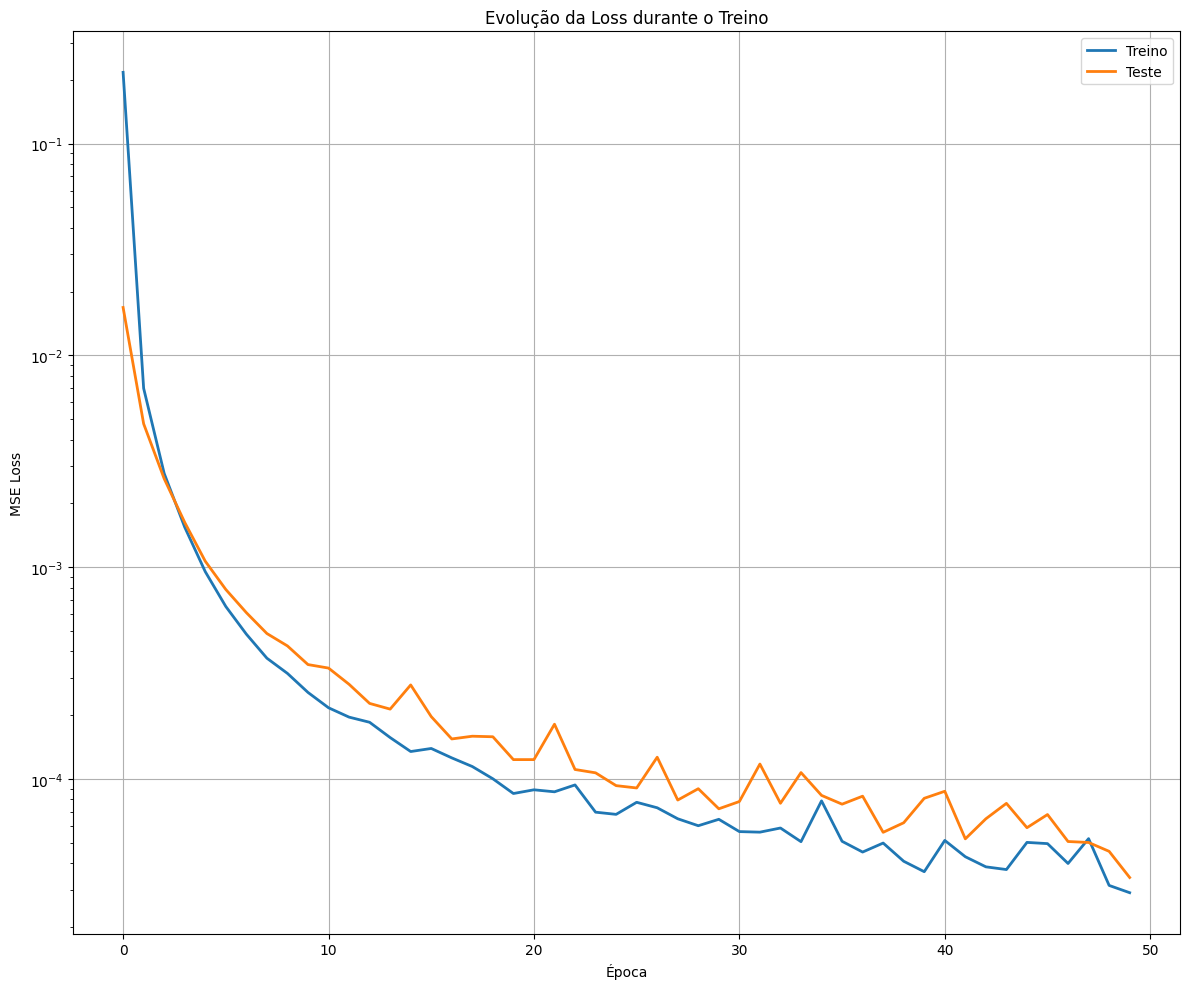


--- Testando exemplo 0 ---
Exemplo 0:
Pontos comparados: 400
Erro médio angular: 1.4509 rad
Erro máximo th1: 2.7782 rad
Erro máximo th2: 2.9682 rad


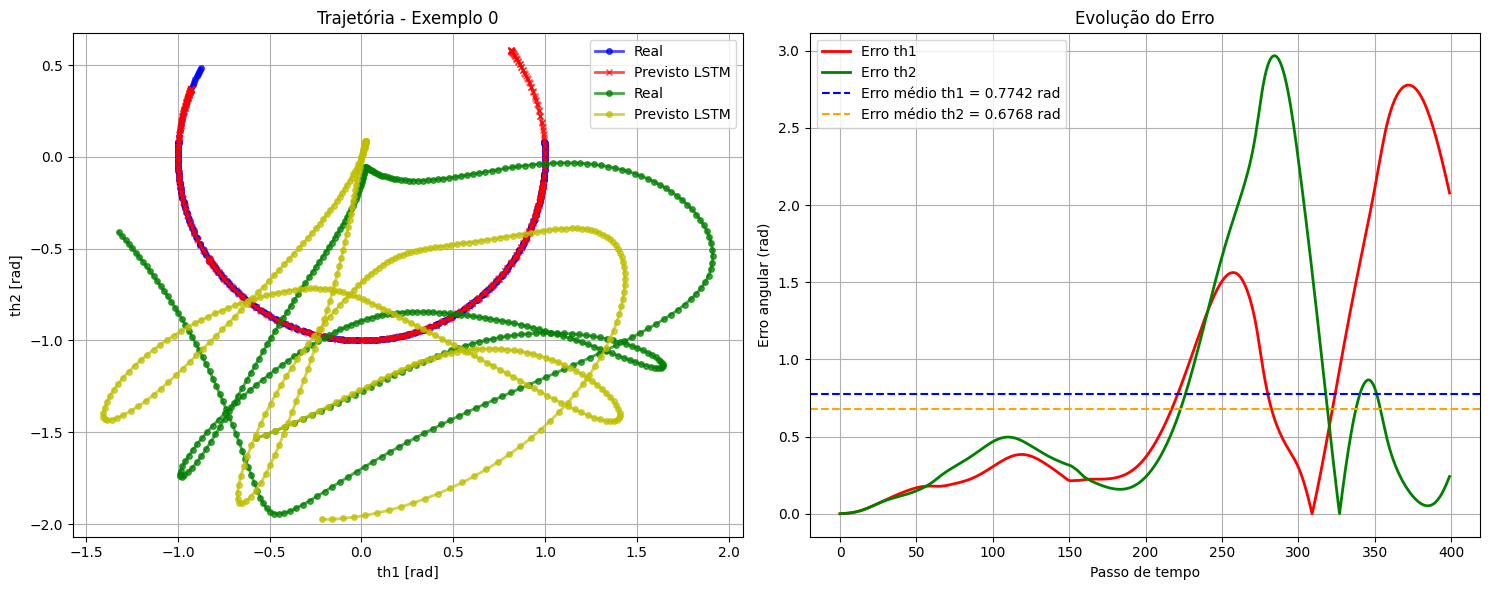


--- Testando exemplo 55 ---
Exemplo 55:
Pontos comparados: 345
Erro médio angular: 1.9300 rad
Erro máximo th1: 3.1380 rad
Erro máximo th2: 2.3159 rad


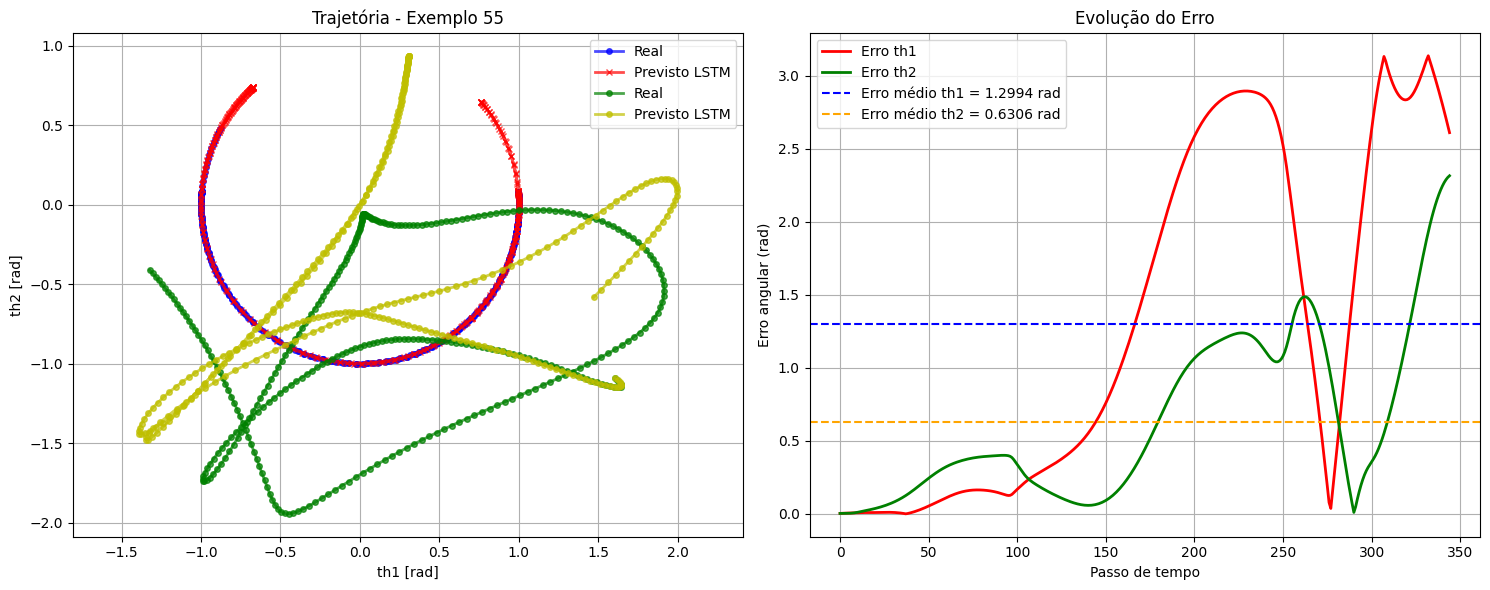


--- Testando exemplo 399 ---
Exemplo 399:
Pontos comparados: 400
Erro médio angular: 1.5674 rad
Erro máximo th1: 2.6046 rad
Erro máximo th2: 2.9529 rad


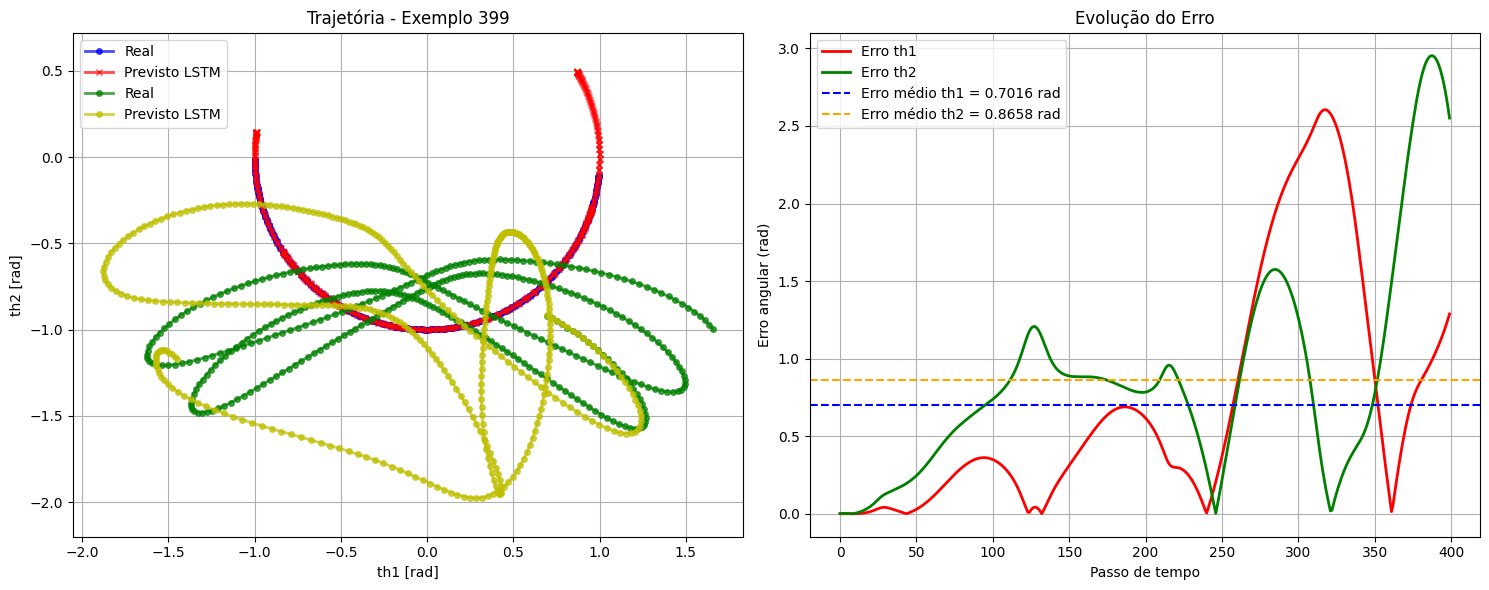


ESTATÍSTICAS FINAIS
Épocas treinadas: 50
Final loss de treino: 0.000029


In [6]:

plots(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples, loss_list, test_loss_list)

In [7]:
#Armazena e aplica inversão do StandardScaler usando tensores PyTorch.
class DifferentiableScaler:
    def __init__(self, scaler, device):
        self.mean = torch.tensor(scaler.mean_[0], dtype=torch.float32, device=device)
        self.std = torch.tensor(scaler.scale_[0], dtype=torch.float32, device=device)

    def inverse_transform(self, data_normalized):
        return data_normalized * self.std + self.mean

# Funçoes de perda física:

def angular_difference(angle1, angle2):
    diff = angle1 - angle2
    return torch.atan2(torch.sin(diff), torch.cos(diff))

def unwrap_angles_robust(theta):
    theta_unwrapped = theta.clone()
    diff = theta[:, 1:] - theta[:, :-1]
    diff_corrected = torch.atan2(torch.sin(diff), torch.cos(diff))
    for i in range(1, theta.shape[1]):
        theta_unwrapped[:, i] = theta_unwrapped[:, i-1] + diff_corrected[:, i-1]
    return theta_unwrapped


def double_pendulum_energy(theta1, theta2, theta1_dot, theta2_dot, L1=1.0, L2=1.0, m1=1.0, m2=1.0, g=9.81):
    delta_theta = theta1 - theta2

    v1_sq = (L1 * theta1_dot) ** 2
    v2_sq = (L1 * theta1_dot) ** 2 + (L2 * theta2_dot) ** 2 + 2 * L1 * L2 * theta1_dot * theta2_dot * torch.cos(delta_theta)

    K = 0.5 * m1 * v1_sq + 0.5 * m2 * v2_sq
    U = -m1 * g * L1 * torch.cos(theta1) - m2 * g * (L1 * torch.cos(theta1) + L2 * torch.cos(theta2))
    return K + U

#perda pela conservacao de energia

def physics_loss_energy(pred_seq, dt, w_scaler):
    batch_size, seq_len, _ = pred_seq.shape

    if seq_len < 2:
        return torch.tensor(0.0, device=pred_seq.device)

    theta1 = torch.atan2(pred_seq[:, :, 0], pred_seq[:, :, 1])
    theta2 = torch.atan2(pred_seq[:, :, 2], pred_seq[:, :, 3])

    w1_norm = pred_seq[:, :, 4]
    w2_norm = pred_seq[:, :, 5]

    w1_all = w_scaler.inverse_transform(w1_norm)
    w2_all = w_scaler.inverse_transform(w2_norm)

    theta1_unwrapped = unwrap_angles_robust(theta1)
    theta2_unwrapped = unwrap_angles_robust(theta2)

    theta1_E = theta1_unwrapped[:, :-1]
    theta2_E = theta2_unwrapped[:, :-1]
    w1_E = w1_all[:, :-1]
    w2_E = w2_all[:, :-1]

    E_current = double_pendulum_energy(theta1_E, theta2_E, w1_E, w2_E)
    E_next = double_pendulum_energy(theta1_unwrapped[:, 1:], theta2_unwrapped[:, 1:],
                                    w1_all[:, 1:], w2_all[:, 1:])

    if E_current.shape[1] >= 1:
        E_diff = E_next - E_current
        E_mean_abs = torch.mean(torch.abs(E_current)) + 1e-8
        energy_loss = torch.mean((E_diff / E_mean_abs) ** 2)
    else:
        energy_loss = torch.tensor(0.0, device=pred_seq.device)

    return energy_loss


# Perda pela equação diferencial de movimento


def double_pendulum_accel(theta1, theta2, w1, w2, L1=1.0, L2=1.0, m1=1.0, m2=1.0, g=9.81):
    delta = theta1 - theta2
    cos_delta = torch.cos(delta)
    sin_delta = torch.sin(delta)

    M11 = (m1 + m2) * L1
    M12 = m2 * L2 * cos_delta
    M21 = (m1 + m2) * L1 * cos_delta
    M22 = m2 * L2

    D = M11 * M22 - M12 * M21

    f1 = -m2 * L2 * w2**2 * sin_delta - (m1 + m2) * g * torch.sin(theta1)
    f2 = m2 * L1 * w1**2 * sin_delta - m2 * g * torch.sin(theta2)

    num1 = (-g * (2 * m1 + m2) * torch.sin(theta1)
            - m2 * g * torch.sin(theta1 - 2 * theta2)
            - 2 * torch.sin(theta1 - theta2) * m2 * (w2**2 * L2 + w1**2 * L1 * torch.cos(theta1 - theta2)))
    den = L1 * (2 * m1 + m2 - m2 * torch.cos(2 * theta1 - 2 * theta2))
    ddot1 = num1 / den

    num2 = (2 * torch.sin(theta1 - theta2) * (w1**2 * L1 * (m1 + m2) + g * (m1 + m2) * torch.cos(theta1) + w2**2 * L2 * m2 * torch.cos(theta1 - theta2)))
    den = L2 * (2 * m1 + m2 - m2 * torch.cos(2 * theta1 - 2 * theta2))
    ddot2 = num2 / den
    return ddot1, ddot2


def physics_loss_edm(input_state_t, output_state_t1, dt, w_scaler):
    theta1_t = torch.atan2(input_state_t[:, 0], input_state_t[:, 1])
    theta2_t = torch.atan2(input_state_t[:, 2], input_state_t[:, 3])

    w1_t = w_scaler.inverse_transform(input_state_t[:, 4])
    w2_t = w_scaler.inverse_transform(input_state_t[:, 5])

    ddot1_phys, ddot2_phys = double_pendulum_accel(theta1_t, theta2_t, w1_t, w2_t)

    w1_t1 = w_scaler.inverse_transform(output_state_t1[:, 4])
    w2_t1 = w_scaler.inverse_transform(output_state_t1[:, 5])

    ddot1_pred = (w1_t1 - w1_t) / dt
    ddot2_pred = (w2_t1 - w2_t) / dt

    residual_loss = (
        torch.mean((ddot1_pred - ddot1_phys) ** 2) +
        torch.mean((ddot2_pred - ddot2_phys) ** 2)
    ) / 2

    return residual_loss

diff_w_scaler = DifferentiableScaler(scaler_w, device)

In [8]:
loss_list = []
test_loss_list = []
physics_loss_list = []


#Treino pela perda com equacao diferencial de movimento
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_phys_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss_data = error(outputs, targets)

        phys_seq = torch.cat([inputs[:, -10:, :], outputs.unsqueeze(1)], dim=1)

        input_state_t = inputs[:, -1, :]

        output_state_t1 = outputs

        loss_phys = physics_loss_edm(input_state_t, output_state_t1, dt=0.01, w_scaler=diff_w_scaler)

        #lambda_phys = 1e-5
        lambda_phys = 1e-6
        loss = loss_data + lambda_phys * loss_phys

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_phys_loss += loss_phys.item() if isinstance(loss_phys, torch.Tensor) else loss_phys

    avg_train_loss = epoch_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_pred = model(x_test)
            test_loss += error(y_pred, y_test).item()

    avg_test_loss = test_loss / len(test_loader)
    scheduler.step(avg_test_loss)

    loss_list.append(avg_train_loss)
    test_loss_list.append(avg_test_loss)
    physics_loss_list.append(avg_phys_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Test: {avg_test_loss:.6f} | "
              f"Phys: {avg_phys_loss:.6f}")



Epoch 1/50 | Train: 0.003124 | Test: 0.000246 | Phys: 930.821650
Epoch 10/50 | Train: 0.000028 | Test: 0.000031 | Phys: 6.873847
Epoch 20/50 | Train: 0.000020 | Test: 0.000026 | Phys: 5.179670
Epoch 30/50 | Train: 0.000025 | Test: 0.000032 | Phys: 6.014258
Epoch 40/50 | Train: 0.000019 | Test: 0.000034 | Phys: 4.521306
Epoch 50/50 | Train: 0.000016 | Test: 0.000025 | Phys: 3.502472


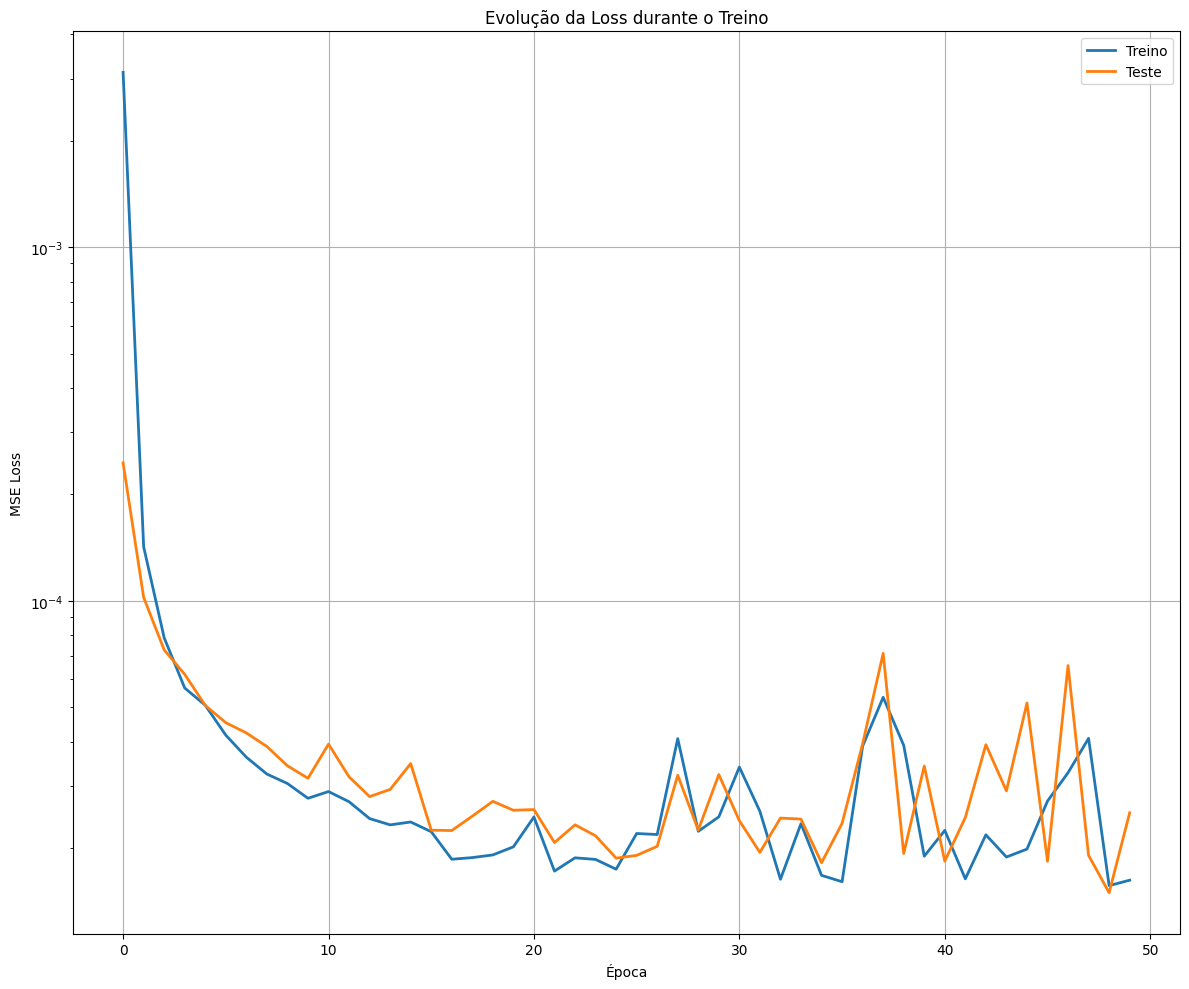


--- Testando exemplo 0 ---
Exemplo 0:
Pontos comparados: 400
Erro médio angular: 1.7393 rad
Erro máximo th1: 2.8810 rad
Erro máximo th2: 2.4345 rad


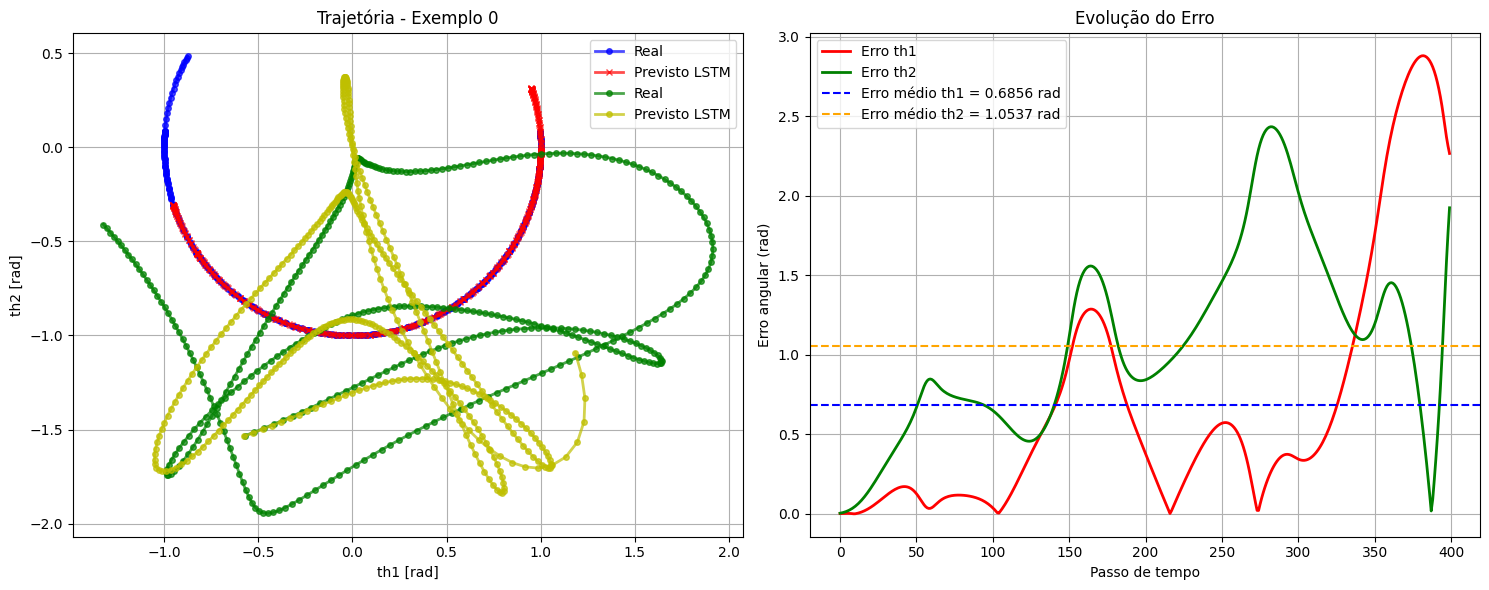


--- Testando exemplo 55 ---
Exemplo 55:
Pontos comparados: 345
Erro médio angular: 1.7817 rad
Erro máximo th1: 3.1341 rad
Erro máximo th2: 3.1380 rad


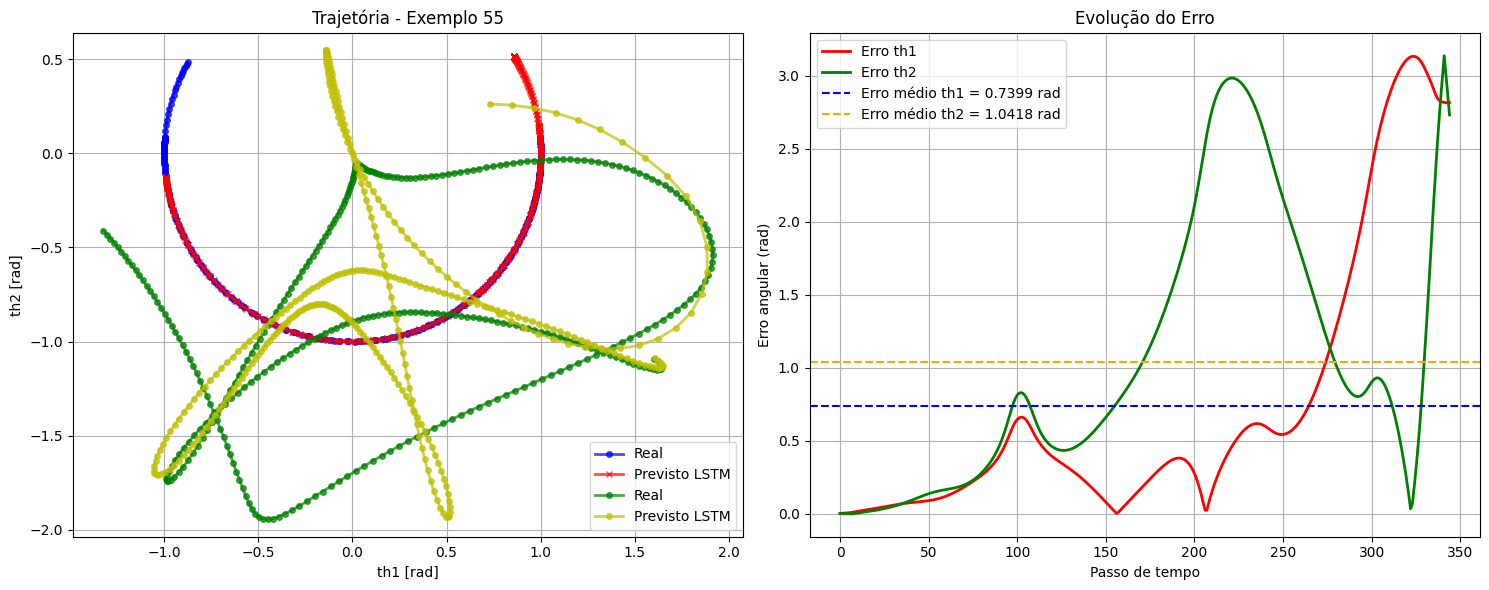


--- Testando exemplo 399 ---
Exemplo 399:
Pontos comparados: 400
Erro médio angular: 2.1680 rad
Erro máximo th1: 3.1355 rad
Erro máximo th2: 3.1252 rad


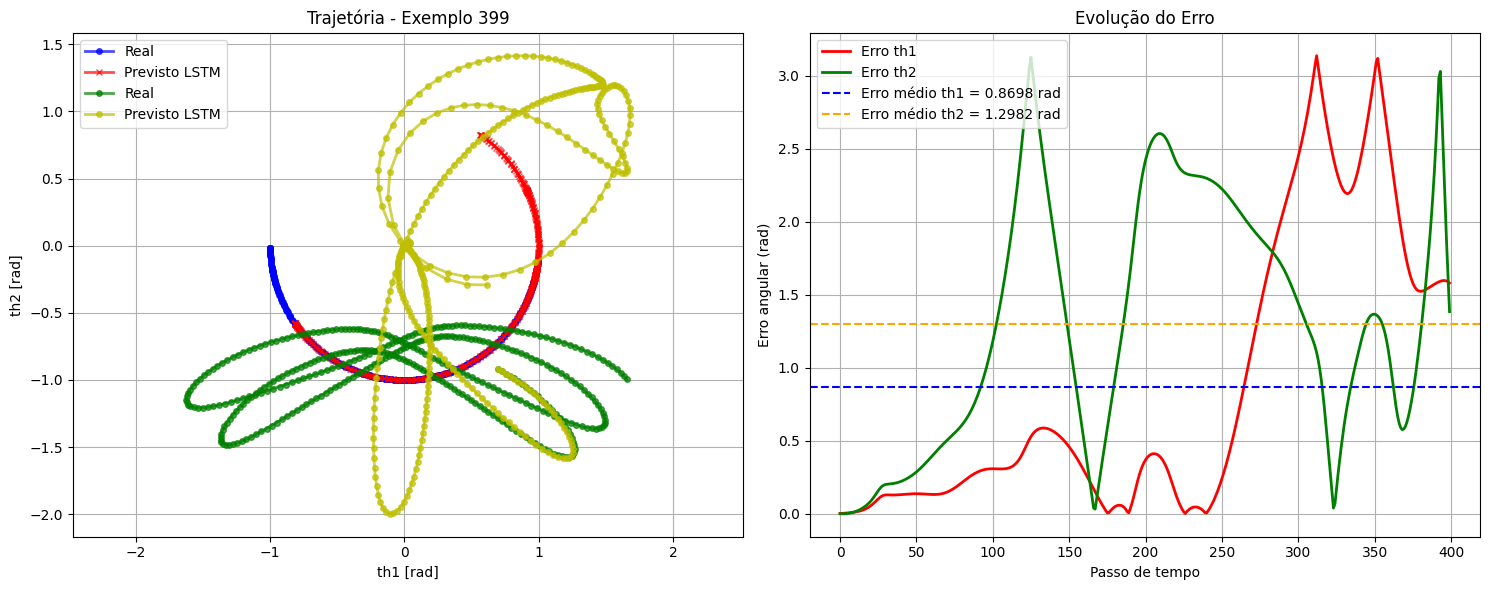


ESTATÍSTICAS FINAIS
Épocas treinadas: 50
Final loss de treino: 0.000016


In [9]:
plots(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples, loss_list, test_loss_list)

In [10]:
loss_list = []
test_loss_list = []
physics_loss_list = []

#treino pela conservacao de energia
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_phys_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss_data = error(outputs, targets)

        phys_seq = torch.cat([inputs[:, -10:, :], outputs.unsqueeze(1)], dim=1)

        if phys_seq.shape[1] >= 2:
            loss_phys = physics_loss_energy(phys_seq, dt=0.01, w_scaler=diff_w_scaler)
        else:
            loss_phys = torch.tensor(0.0, device=device)

        #o peso pode ser muito maior em conservacao de energia: melhor: 20(?)
        lambda_phys = 1
        loss = loss_data + lambda_phys * loss_phys

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_phys_loss += loss_phys.item() if isinstance(loss_phys, torch.Tensor) else loss_phys

    avg_train_loss = epoch_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_pred = model(x_test)
            test_loss += error(y_pred, y_test).item()

    avg_test_loss = test_loss / len(test_loader)
    scheduler.step(avg_test_loss)

    loss_list.append(avg_train_loss)
    test_loss_list.append(avg_test_loss)
    physics_loss_list.append(avg_phys_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Test: {avg_test_loss:.6f} | "
              f"Phys: {avg_phys_loss:.6f}")



Epoch 1/50 | Train: 0.010738 | Test: 0.000586 | Phys: 0.004277
Epoch 10/50 | Train: 0.000243 | Test: 0.000069 | Phys: 0.000191
Epoch 20/50 | Train: 0.000202 | Test: 0.000031 | Phys: 0.000179
Epoch 30/50 | Train: 0.000193 | Test: 0.000028 | Phys: 0.000176
Epoch 40/50 | Train: 0.000200 | Test: 0.000028 | Phys: 0.000179
Epoch 50/50 | Train: 0.000218 | Test: 0.000024 | Phys: 0.000190


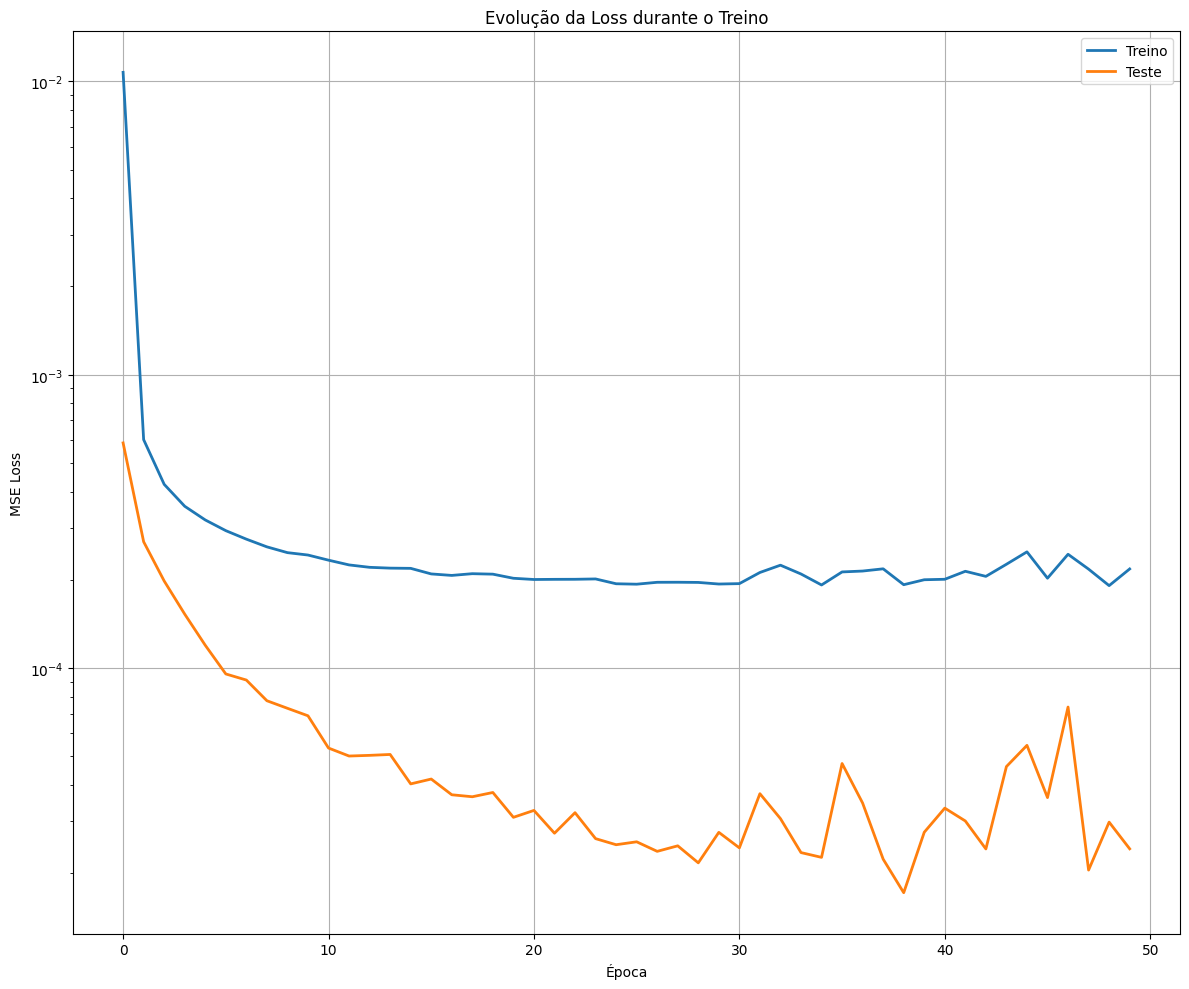


--- Testando exemplo 0 ---
Exemplo 0:
Pontos comparados: 400
Erro médio angular: 1.9743 rad
Erro máximo th1: 3.1051 rad
Erro máximo th2: 3.1376 rad


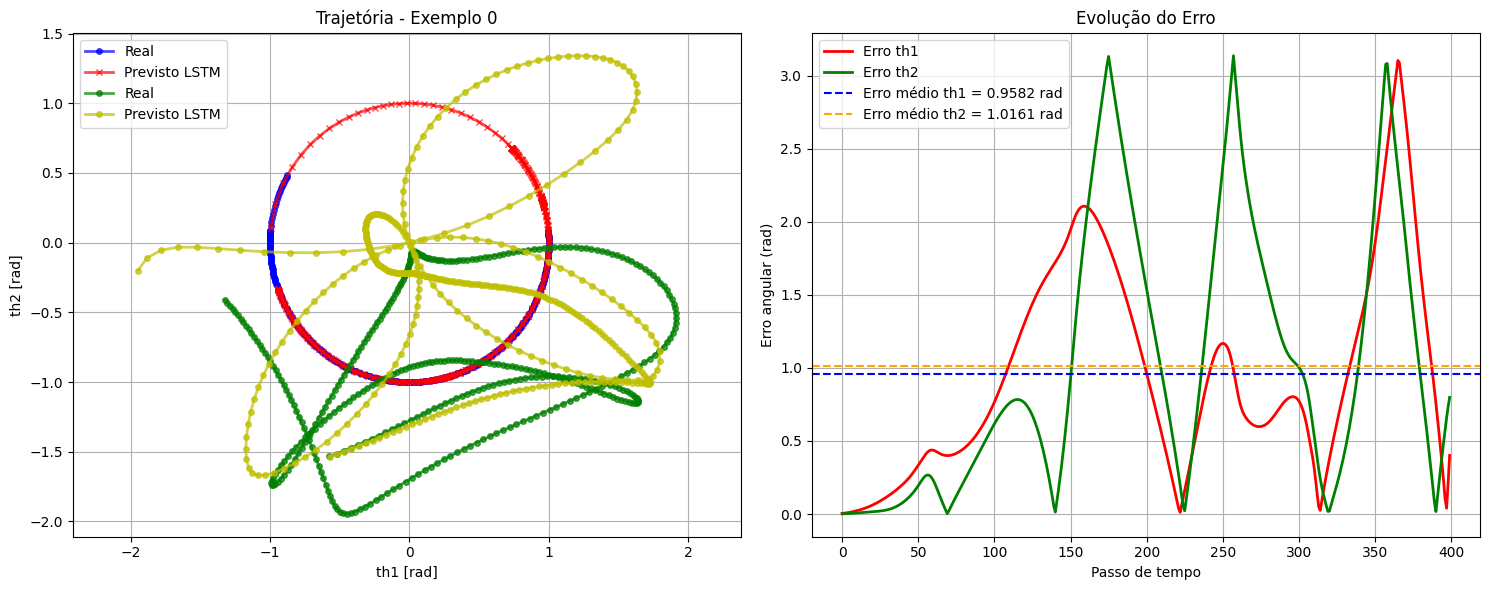


--- Testando exemplo 55 ---
Exemplo 55:
Pontos comparados: 345
Erro médio angular: 1.7037 rad
Erro máximo th1: 1.7161 rad
Erro máximo th2: 3.1385 rad


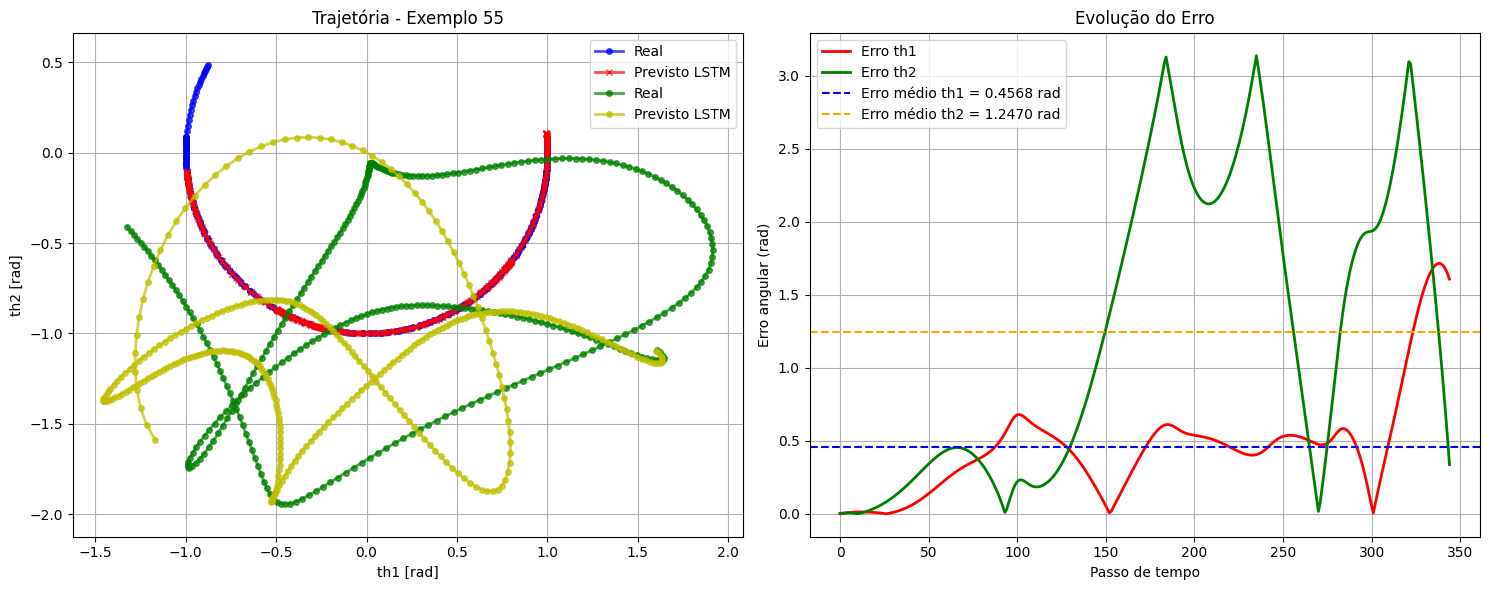


--- Testando exemplo 399 ---
Exemplo 399:
Pontos comparados: 400
Erro médio angular: 1.1374 rad
Erro máximo th1: 1.7446 rad
Erro máximo th2: 1.4357 rad


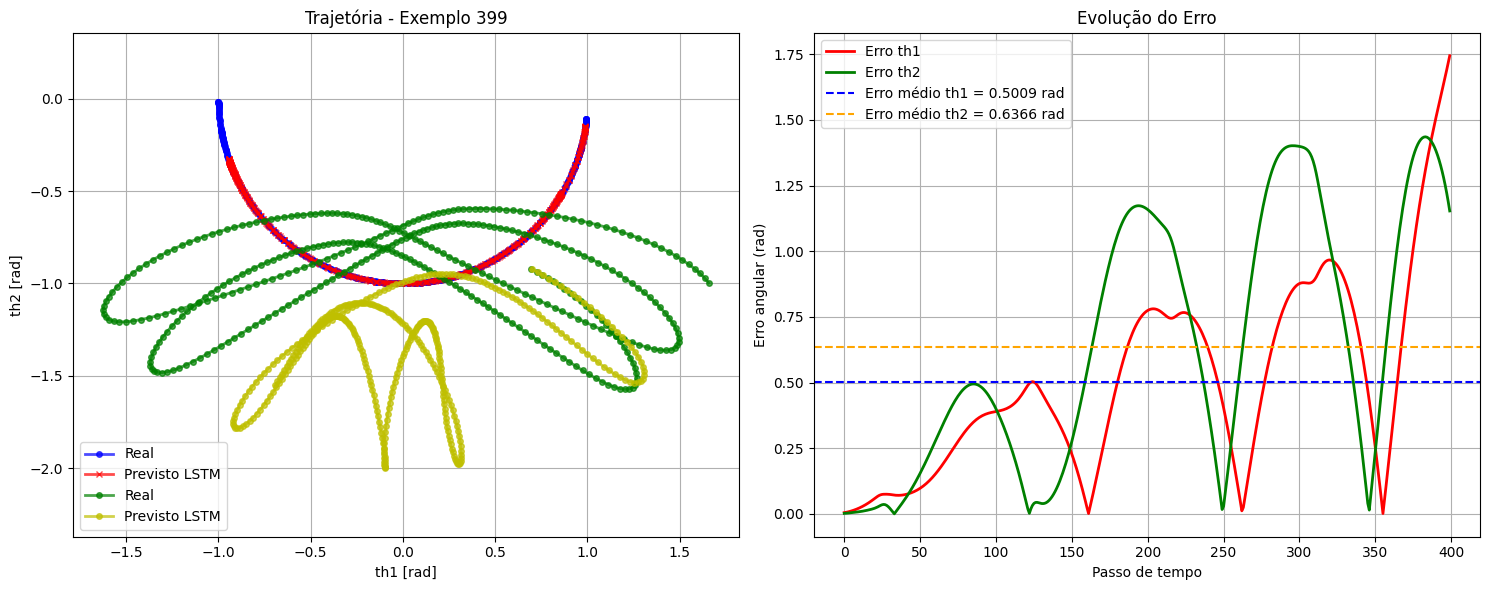


ESTATÍSTICAS FINAIS
Épocas treinadas: 50
Final loss de treino: 0.000218


In [11]:
plots(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples, loss_list, test_loss_list)

In [12]:
loss_list = []
test_loss_list = []
physics_loss_list = []

#treino pela conservacao de energia + eom
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_phys_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss_data = error(outputs, targets)

        phys_seq = torch.cat([inputs[:, -10:, :], outputs.unsqueeze(1)], dim=1)

        if phys_seq.shape[1] >= 2:
            loss_energy = physics_loss_energy(phys_seq, dt=0.01, w_scaler=diff_w_scaler)
        else:
            loss_energy = torch.tensor(0.0, device=device)

        input_state_t = inputs[:, -1, :]

        output_state_t1 = outputs

        loss_eom = physics_loss_edm(input_state_t, output_state_t1, dt=0.01, w_scaler=diff_w_scaler)

        #lambda_phys = 1e-3
        lambda_energy = 1
        lambda_motion = 1e-6
        loss = loss_data + lambda_motion * loss_eom + lambda_energy * loss_energy

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_phys_loss += loss_phys.item() if isinstance(loss_phys, torch.Tensor) else loss_phys

    avg_train_loss = epoch_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_pred = model(x_test)
            test_loss += error(y_pred, y_test).item()

    avg_test_loss = test_loss / len(test_loader)
    scheduler.step(avg_test_loss)

    loss_list.append(avg_train_loss)
    test_loss_list.append(avg_test_loss)
    physics_loss_list.append(avg_phys_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Test: {avg_test_loss:.6f} | "
              f"Phys: {avg_phys_loss:.6f}")

Epoch 1/50 | Train: 0.000271 | Test: 0.000089 | Phys: 0.000205
Epoch 10/50 | Train: 0.000201 | Test: 0.000021 | Phys: 0.000205
Epoch 20/50 | Train: 0.000273 | Test: 0.000030 | Phys: 0.000205
Epoch 30/50 | Train: 0.000195 | Test: 0.000016 | Phys: 0.000205
Epoch 40/50 | Train: 0.000212 | Test: 0.000020 | Phys: 0.000205
Epoch 50/50 | Train: 0.000211 | Test: 0.000028 | Phys: 0.000205


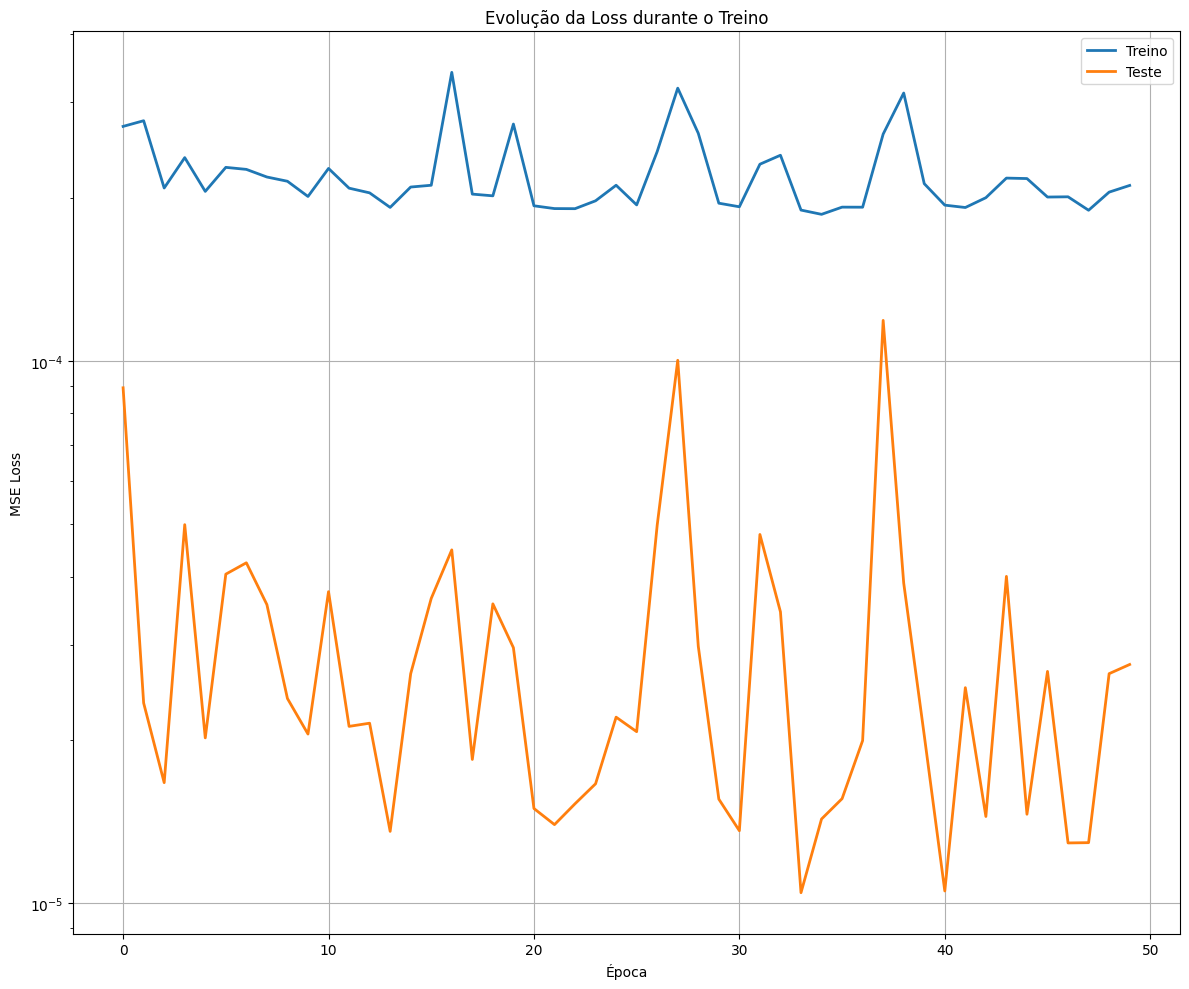


--- Testando exemplo 0 ---
Exemplo 0:
Pontos comparados: 400
Erro médio angular: 1.4841 rad
Erro máximo th1: 1.8935 rad
Erro máximo th2: 3.1281 rad


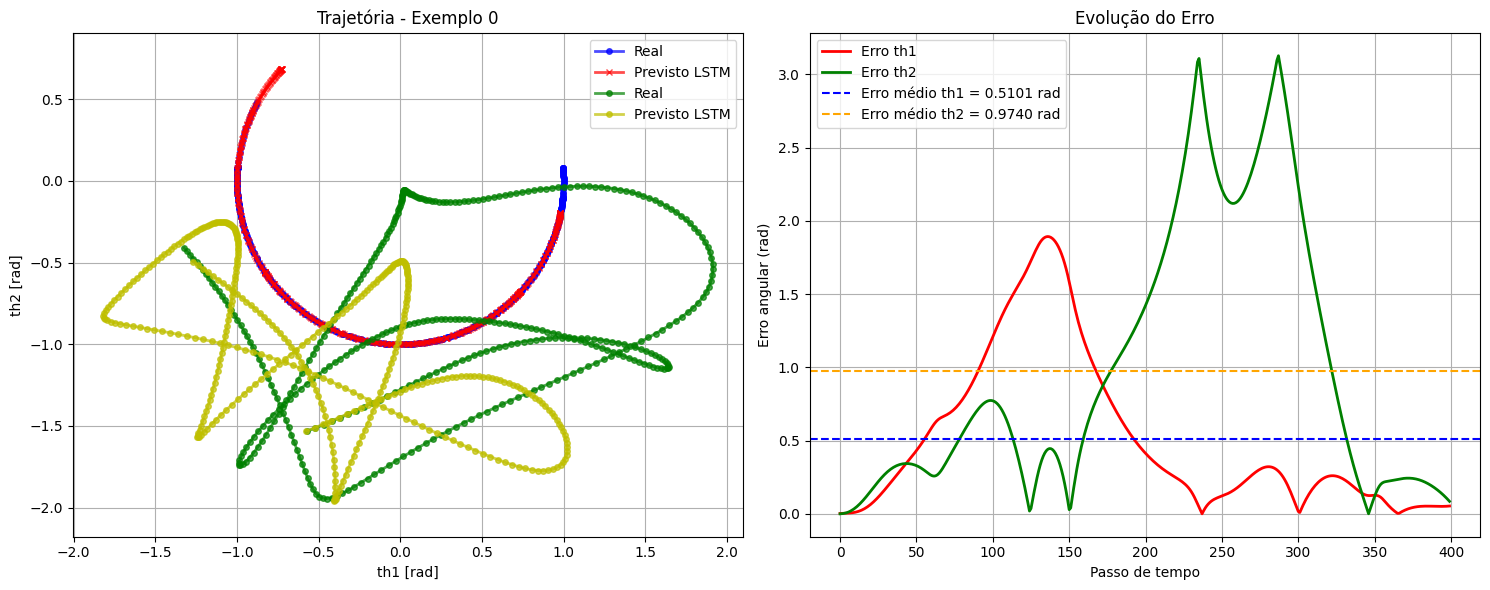


--- Testando exemplo 55 ---
Exemplo 55:
Pontos comparados: 345
Erro médio angular: 2.8217 rad
Erro máximo th1: 3.1200 rad
Erro máximo th2: 3.1303 rad


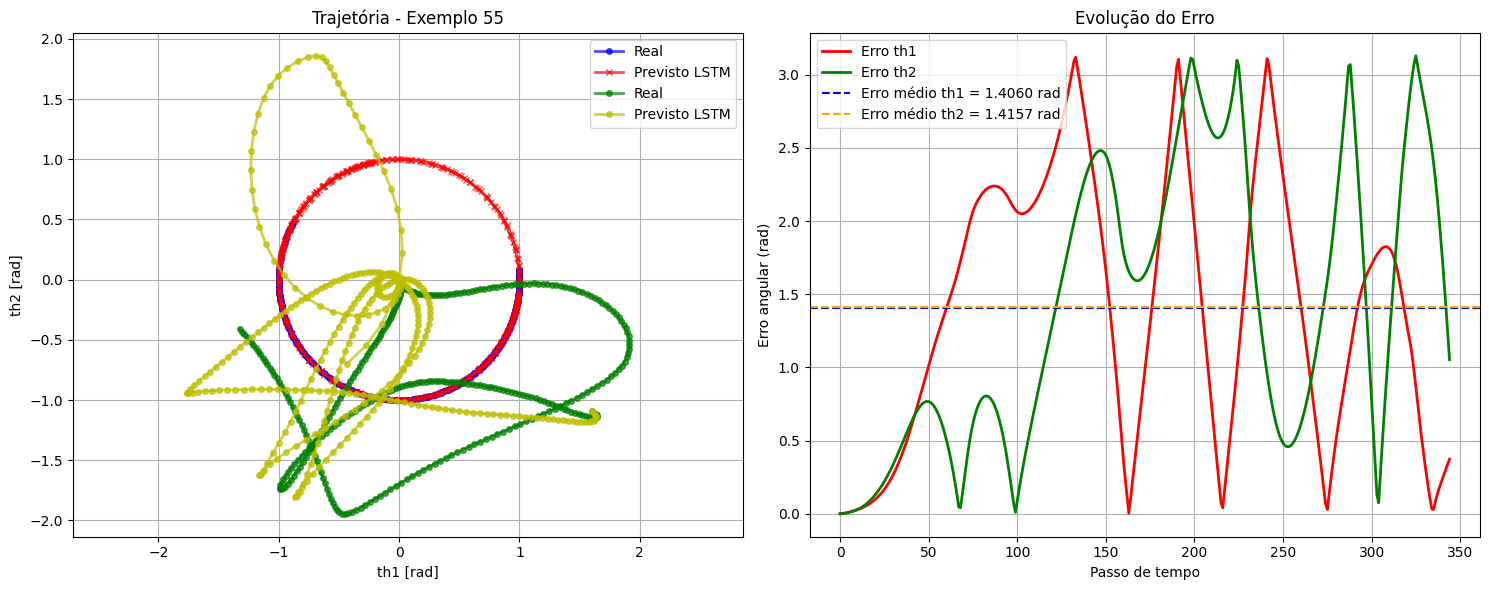


--- Testando exemplo 399 ---
Exemplo 399:
Pontos comparados: 400
Erro médio angular: 2.9841 rad
Erro máximo th1: 3.1393 rad
Erro máximo th2: 3.1284 rad


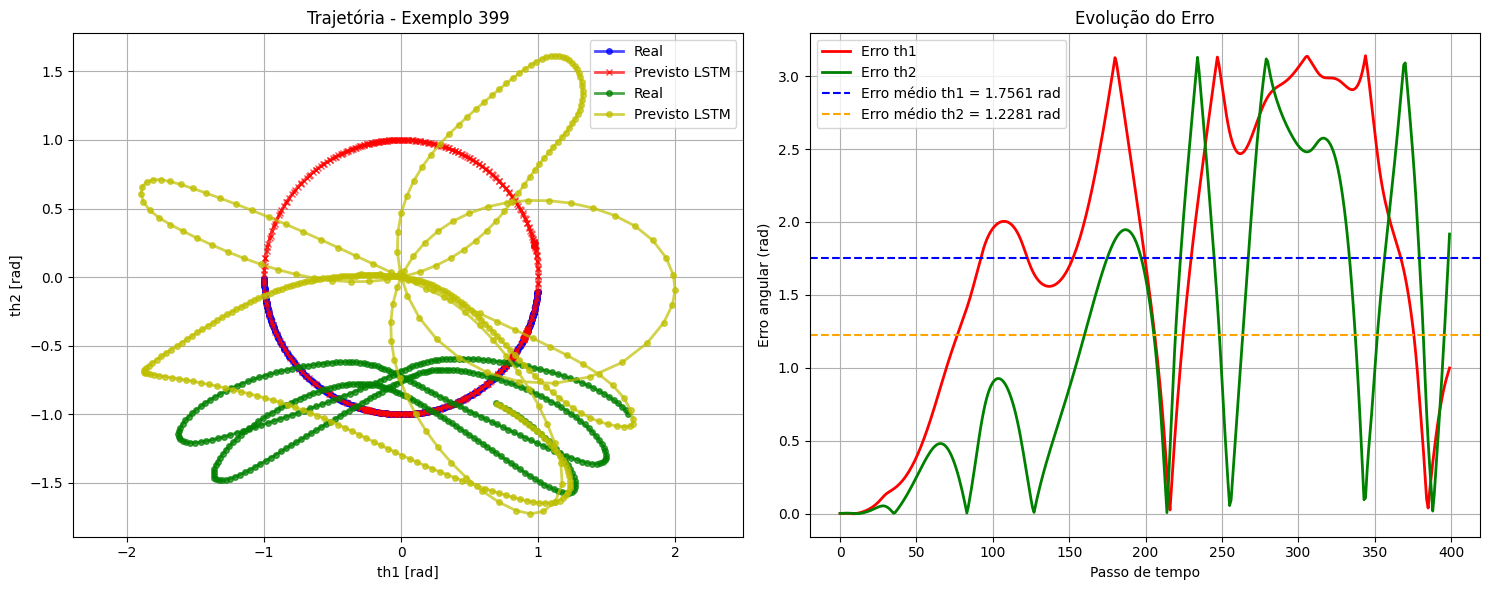


ESTATÍSTICAS FINAIS
Épocas treinadas: 50
Final loss de treino: 0.000211


In [13]:
plots(datasets, featuresTest, model, L1, L2, idx_test, pos_test, window, test_examples, loss_list, test_loss_list)